<a href="https://colab.research.google.com/github/mhkbin/AIML-Lab/blob/main/Statement3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem 3: Checking Routes Between Cities Using DFS Problem Statement: A small road network connects several cities. Write a Python program using DFS that: 1. Checks whether a route exists between two given cities. 2. Finds all separate groups of cities that are connected to each other but not to any other group (these are called connected components).



Route exists between Bankura and Ranchi

Connected Components:
Component 1 : ['Bankura', 'Durgapur', 'Kolkata', 'Asansol', 'Ranchi', 'Dhanbad']


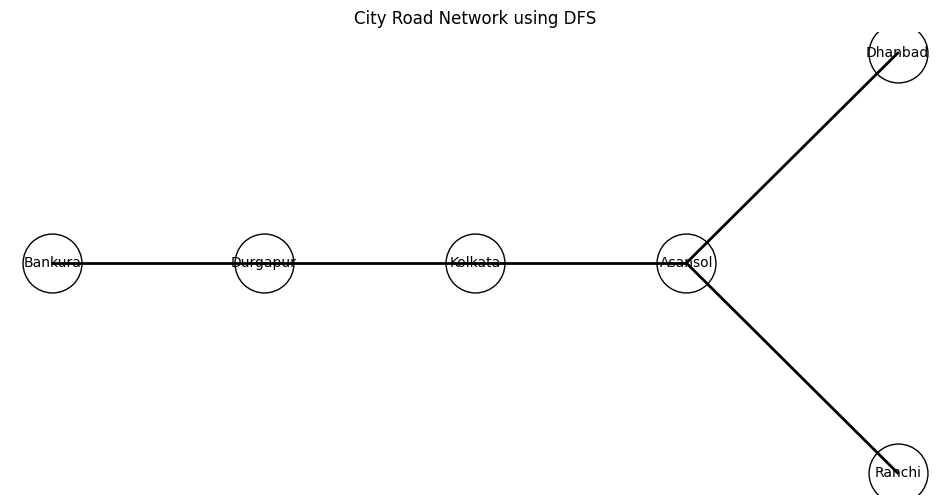

In [ ]:
import matplotlib.pyplot as plt

# Adjacency list
graph = {
    'Bankura': ['Durgapur'],
    'Durgapur': ['Bankura', 'Kolkata'],
    'Kolkata': ['Durgapur', 'Asansol'],
    'Asansol': ['Kolkata', 'Dhanbad', 'Ranchi'],
    'Dhanbad': ['Asansol'],
    'Ranchi': ['Asansol']
}


# DFS to check whether a route exists
def route_exists(graph, start, destination, visited=None):

    if visited is None:
        visited = []

    if start == destination:
        return True

    visited.append(start)

    for city in graph[start]:
        if city not in visited:
            if route_exists(graph, city, destination, visited):
                return True

    return False


# Find connected components using DFS
def find_components(graph):

    visited = []
    components = []

    for city in graph:

        if city not in visited:

            component = []
            stack = [city]

            while stack:

                current = stack.pop()

                if current not in visited:
                    visited.append(current)
                    component.append(current)

                    for neighbour in graph[current]:
                        if neighbour not in visited:
                            stack.append(neighbour)

            components.append(component)

    return components


# Check route between two cities
start_city = 'Bankura'
destination_city = 'Ranchi'

if route_exists(graph, start_city, destination_city):
    print("Route exists between", start_city, "and", destination_city)
else:
    print("No route exists between", start_city, "and", destination_city)


# Find connected components
components = find_components(graph)

print("\nConnected Components:")

for i, component in enumerate(components, start=1):
    print("Component", i, ":", component)


# Graphical representation using Matplotlib

positions = {
    'Bankura': (0, 2),
    'Durgapur': (2, 2),
    'Kolkata': (4, 2),
    'Asansol': (6, 2),
    'Dhanbad': (8, 3),
    'Ranchi': (8, 1)
}

plt.figure(figsize=(12, 6))

# Draw roads
edges = [
    ('Bankura', 'Durgapur'),
    ('Durgapur', 'Kolkata'),
    ('Kolkata', 'Asansol'),
    ('Asansol', 'Dhanbad'),
    ('Asansol', 'Ranchi')
]

for city1, city2 in edges:

    x1, y1 = positions[city1]
    x2, y2 = positions[city2]

    plt.plot([x1, x2], [y1, y2], 'k-', linewidth=2)


# Draw cities
for city, (x, y) in positions.items():

    plt.scatter(
        x, y,
        s=1800,
        facecolors='white',
        edgecolors='black'
    )

    plt.text(
        x, y,
        city,
        ha='center',
        va='center',
        fontsize=10
    )


plt.title("City Road Network using DFS")

plt.axis('off')
plt.show()